## Lab 6
<div style="border: 2px dotted green; padding: 10px; text-align: center; font-size: 20px; font-weight: bold; color: green">
Stochastic Gradient Descent (SGD) and Mini-Batch Gradient Descent
</div>
</br>
In this lab, you will implement **Stochastic Gradient Descent (SGD)** and **Mini-Batch Gradient Descent** from scratch using NumPy to train a Multiple Linear Regression model. You will compare their convergence behaviour and evaluate their performance using **Mean Squared Error (MSE)**.

## Learning Objectives

After completing this lab, you will be able to:

- Load and visualize a dataset.
- Analyze feature relationships using a correlation heatmap.
- Implement prediction and loss computation.
- Implement Stochastic Gradient Descent (SGD).
- Implement Mini-Batch Gradient Descent.
- Compare SGD and Mini-Batch Gradient Descent.
- Visualize convergence using loss curves.
- Evaluate regression models using Mean Squared Error (MSE).

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


%load_ext autoreload
%autoreload 2

from mlr_gradient_descent_minibatch import *

print("Setup complete.")


Setup complete.


### Load the Dataset
Load the dataset into a Pandas DataFrame.

In [2]:
df = pd.read_csv("student_clean_dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (3000, 12)


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18,Female,Electronics,8,76,19,86,Pass,A+,Placed,7.44
1,ST002,20,Female,Computer Science,5,84,12,53,Pass,C,Placed,3.38
2,ST003,19,Male,Mechanical,6,90,14,74,Pass,A,Placed,7.30
3,ST004,19,Female,Electronics,5,75,12,54,Pass,C,Placed,3.45
4,ST005,18,Male,Computer Science,6,90,16,74,Pass,A,Placed,7.91


# Prepare the Dataset

The function load_data()

extracts the independent variables:
- Study_Hours, Attendance, Assignments, Age
- 
and the dependent variable:
- Exam_Score

An intercept column containing all ones is then added to the feature matrix.
This allows the regression model to learn the bias term.

In [3]:
mlr_features = ["Study_Hours","Attendance","Assignments","Age"]

In [4]:
def load_data():

    X = df[["Study_Hours","Attendance","Assignments","Age"]].to_numpy(dtype = float)
    y = df["Exam_Score"].to_numpy(dtype = float)
    return X, y

In [5]:
X_mlr, y_mlr = load_data()

In [6]:
X_mlr.shape

(3000, 4)

### Implement Stochastic Gradient Descent (SGD)

The function

gradient_descent_sgd()

implements SGD from scratch.

The algorithm performs the following operations for every epoch:

- Randomly shuffle the dataset.
- Select one training example at a time.
- Predict the output.
- Compute the residual.
- Compute the gradient using that single sample.
- Immediately update the model parameters.
- Compute the overall loss after completing the epoch.

The loss is printed every "n" epochs.

### Define Helper Functions

Before implementing Gradient Descent, several reusable helper functions are created.


### Prediction Function

predict(X, theta)

Computes the predicted values using

$$
\hat{y}=X\theta
$$

### Residual Function

compute_residual(y, predictions)

Calculates the prediction error

$$
Residual=\hat{y}-y
$$

### Loss Function

compute_loss(residual)


Computes the Mean Squared Error

$$
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2
$$

This value is used to monitor how well the model is learning.

### Gradient Function

compute_gradient(X, residual)

Computes the gradient of the Mean Squared Error using

$$
\nabla J(\theta)=\frac{2}{n}X^T(X\theta-y)
$$

This gradient indicates the direction in which the parameters should be updated.

### Parameter Update Function

update_theta(theta, gradient, alpha)

Updates the parameters using

$$
\theta=\theta-\alpha\nabla J(\theta)
$$

where

- **θ** represents the model parameters.
- **α** is the learning rate.

<div style="border: 2px solid red; padding: 10px; text-align: center; font-size: 15px; color: red; font-style: italic;">
Note: minibatch_gradient_descent_mlr() will handle both SGD and Mini-Batch Gradient Descent.</br>
For <b>SGD</b> batch size will be <b>1</b>, and for <b>Mini-batch</b> it can be <b>anything > 1</b>
</div>

<div style="border: 2px solid blue; padding: 10px; text-align: center; font-size: 20px; font-weight: bold; color: blue">
STOCHASTIC GRADIENT DESCENT
</div>

### Initialize MLR Parameters

If there are `p` features, the design matrix `H` contains:

- one column of ones for the intercept
- `p` feature columns

Therefore, the parameter vector contains `p + 1` values.

In [7]:
n_features = X_mlr.shape[1]+1
initial_weights = np.zeros(n_features)
print("Number of MLR parameters:", n_features)
print("Initial weights:", initial_weights)

Number of MLR parameters: 5
Initial weights: [0. 0. 0. 0. 0.]


### SGD Hyperparameters

In this cell, we define the hyperparameters for **Stochastic Gradient Descent (SGD)**:

- **Learning Rate:** `0.000001` — controls the step size for updating the model parameters.
- **Epochs:** `200` — the number of complete passes through the training dataset.
- **Batch Size:** `1` — one training sample is used for each parameter update, making this **Stochastic Gradient Descent (SGD)**.

In [8]:
learning_rate_mlr_sgd = 0.000001
epochs_mlr_sgd = 200
batch_size_sgd = 1

## Train the Model using Stochastic Gradient Descent (SGD)

Initialize the parameter vector with zeros and train the Multiple Linear Regression model using **Stochastic Gradient Descent (SGD)**.

The following code:

- Initializes the model parameters (`θ`) to zero.
- Trains the model using the `minibatch_gradient_descent_mlr` function.
- Predicts the exam scores using the learned parameters.
- Computes the Mean Squared Error (MSE).
- Displays the learned parameters and the final MSE.

In [9]:
start()
mlr_weights, mlr_loss_history_sgd = minibatch_gradient_descent_mlr(
    X_mlr,
    y_mlr,
    initial_weights,
    learning_rate_mlr_sgd,
    epochs_mlr_sgd,
    batch_size_sgd
)
stop()
runtime_sgd = runtime_in_ms()
print("->Training Time Stochastic Gradient Decent: ",runtime_sgd,"ms")

print("\nFinal MLR parameters:")
for feature, weight in zip(["Intercept"] + mlr_features, mlr_weights):
    print(f"{feature:20s}: {weight}")


n=3000
Epoch   0 | Loss = 238.6000


/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab_6/Lab 6/mlr_gradient_descent_minibatch.py:7: RuntimeWarning: divide by zero encountered in matmul
  return H @ weights
/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab_6/Lab 6/mlr_gradient_descent_minibatch.py:7: RuntimeWarning: overflow encountered in matmul
  return H @ weights
/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab_6/Lab 6/mlr_gradient_descent_minibatch.py:7: RuntimeWarning: invalid value encountered in matmul
  return H @ weights


Epoch 100 | Loss = 10.2053
->Training Time Stochastic Gradient Decent:  3049.9765420000003 ms

Final MLR parameters:
Intercept           : -0.05820957047503947
Study_Hours         : 1.9383634286897296
Attendance          : 0.2163270504710045
Assignments         : 3.482573380236414
Age                 : -0.6253183280073619


### Model Evaluation for SGD

Calculate predictions and evaluate the MLR model using MAE, MSE, RMSE, and R².

In [10]:
mlr_pred = predict_mlr(
    X_mlr,
    mlr_weights
)

mlr_y_mean = find_mean(y_mlr)

mlr_mae = mae(y_mlr, mlr_pred)
mlr_mse = mse(y_mlr, mlr_pred)
mlr_rmse = rmse(y_mlr, mlr_pred)
mlr_r2 = r_square(y_mlr, mlr_pred, mlr_y_mean)

mlr_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "MLR Batch GD": [mlr_mae, mlr_mse, mlr_rmse, mlr_r2]
})

display(mlr_results)


,Metric,MLR Batch GD
0,MAE,2.720651
1,MSE,10.142723
2,RMSE,3.184764
3,R2,0.966479


In [11]:
mlr_coefficients = pd.DataFrame({
    "Parameter": ["Intercept"] + mlr_features,
    "Coefficient": mlr_weights
})

display(mlr_coefficients)


,Parameter,Coefficient
0,Intercept,-0.058210
1,Study_Hours,1.938363
2,Attendance,0.216327
3,Assignments,3.482573
4,Age,-0.625318


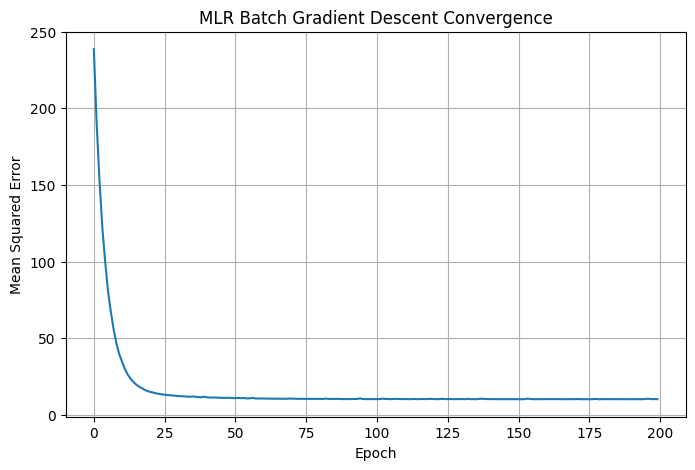

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(mlr_loss_history_sgd)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("MLR Batch Gradient Descent Convergence")
plt.grid(True)
plt.show()


<div style="border: 2px solid blue; padding: 10px; text-align: center; font-size: 20px; font-weight: bold; color: blue">
Mini-Batch Gradient Descent
</div>

<b>The function: minibatch_gradient_descent_mlr()</b> implements Mini-Batch Gradient Descent.

Instead of updating the parameters after every training sample, it performs updates after processing a small batch of samples.

For each epoch, the algorithm:

- Shuffles the dataset.
- Divides the data into batches.
- Computes predictions for one batch.
- Computes the gradient for that batch.
- Updates the parameters.
- Repeats until all batches are processed.
- Computes the loss after completing the epoch.

The loss is displayed every 'n' epochs.

### Mini-Batch Gradient Descent Hyperparameters

In this cell, we define the hyperparameters for **Mini-Batch Gradient Descent**:

- **Learning Rate:** `0.00001` — controls the step size for updating the model parameters.
- **Epochs:** `2000` — the number of complete passes through the training dataset.
- **Batch Size:** `100` — one training sample is used for each parameter update, making this **Mini-Batch Gradient Descent**.

In [13]:
learning_rate_mlr_mbatch = 0.00001
epochs_mlr_mbatch = 2000
batch_size_mbatch =100

## Train for Mini-batch Gradient Descent

In [14]:
initial_weights = np.zeros(n_features)

start()
mlr_weights_mbatch, mlr_loss_history_mbatch = minibatch_gradient_descent_mlr(
    X_mlr,
    y_mlr,
    initial_weights,
    learning_rate_mlr_mbatch,
    epochs_mlr_mbatch,
    batch_size_mbatch
)
stop()
runtime_mbatch = runtime_in_ms()
print("->Training Time: ",runtime_mbatch,"ms")

print("\nFinal MLR parameters:")
for feature, weight in zip(["Intercept"] + mlr_features, mlr_weights_mbatch):
    print(f"{feature:20s}: {weight}")

n=3000
Epoch   0 | Loss = 294.4755
Epoch 100 | Loss = 38.7463
Epoch 200 | Loss = 15.3682
Epoch 300 | Loss = 12.2741
Epoch 400 | Loss = 11.3368
Epoch 500 | Loss = 10.8499
Epoch 600 | Loss = 10.5663
Epoch 700 | Loss = 10.3958
Epoch 800 | Loss = 10.2854


/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab_6/Lab 6/mlr_gradient_descent_minibatch.py:7: RuntimeWarning: divide by zero encountered in matmul
  return H @ weights
/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab_6/Lab 6/mlr_gradient_descent_minibatch.py:7: RuntimeWarning: overflow encountered in matmul
  return H @ weights
/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab_6/Lab 6/mlr_gradient_descent_minibatch.py:7: RuntimeWarning: invalid value encountered in matmul
  return H @ weights


Epoch 900 | Loss = 10.2221
Epoch 1000 | Loss = 10.1839
Epoch 1100 | Loss = 10.1619
Epoch 1200 | Loss = 10.1526
Epoch 1300 | Loss = 10.1378
Epoch 1400 | Loss = 10.1504
Epoch 1500 | Loss = 10.1366
Epoch 1600 | Loss = 10.1294
Epoch 1700 | Loss = 10.1315
Epoch 1800 | Loss = 10.1296
Epoch 1900 | Loss = 10.1268
->Training Time:  495.5194590000005 ms

Final MLR parameters:
Intercept           : -0.05824418528460202
Study_Hours         : 1.9379124368942582
Attendance          : 0.21426735881472425
Assignments         : 3.4823154472541495
Age                 : -0.6257679420808799


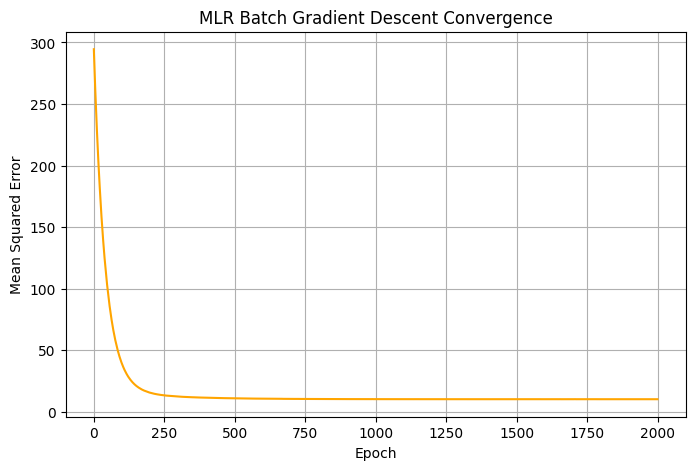

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(mlr_loss_history_mbatch, color = "orange")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("MLR Batch Gradient Descent Convergence")
plt.grid(True)
plt.show()

# Visualize the Convergence of SGD and Mini-Batch Gradient Descent

The optimization process records the Mean Squared Error (MSE) after each epoch.

The following code plots the loss curves of:

- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent**

By comparing these curves, you can observe:

- How quickly each algorithm converges.
- The stability of the optimization process.
- Which algorithm reaches a lower training loss.

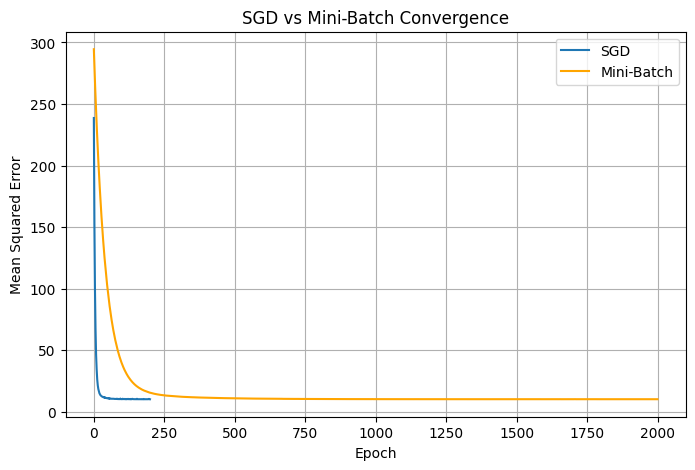

In [16]:
plt.figure(figsize=(8,5))
plt.plot(mlr_loss_history_sgd, label="SGD")
plt.plot(mlr_loss_history_mbatch, label="Mini-Batch", color = "orange")
plt.title("SGD vs Mini-Batch Convergence")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

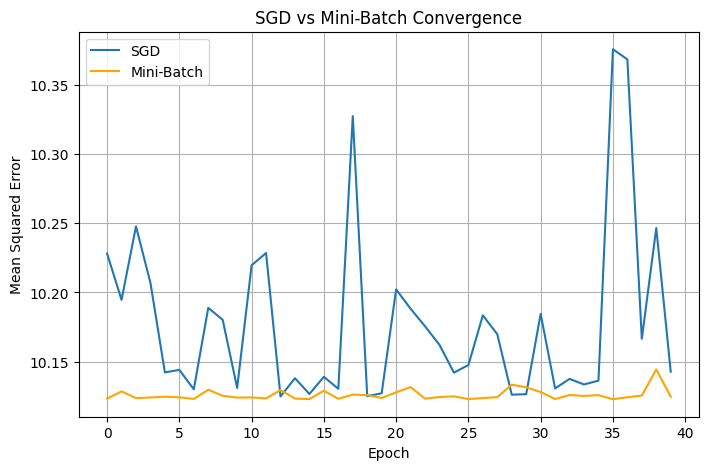

In [17]:
plt.figure(figsize=(8,5))
plt.plot(mlr_loss_history_sgd[-40:], label="SGD")
plt.plot(mlr_loss_history_mbatch[-40:], label="Mini-Batch", color = "orange")
# To check last 40 loss 
# plt.plot(mlr_loss_history_sgd[-40:], label="SGD")
# plt.plot(mlr_loss_history_mbatch[-40:], label="Mini-Batch", color = "orange")
plt.title("SGD vs Mini-Batch Convergence")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
time_comparison = pd.DataFrame({
    "Method": ["SGD", "Mini-Batch"],
    "Batch Size": [batch_size_sgd, batch_size_mbatch,],
    "Training Time (ms)": [runtime_sgd, runtime_mbatch],
    "Epoch": [epochs_mlr_sgd, epochs_mlr_mbatch],
    "Learning Rate": [learning_rate_mlr_sgd, learning_rate_mlr_mbatch],
    "Last loss": [mlr_loss_history_sgd[-1], mlr_loss_history_mbatch[-1]]
})

display(time_comparison)

if runtime_sgd < runtime_mbatch:
    print(f"Faster method: SGD ({runtime_sgd:.2f} ms)")
    print(f"SGD is {runtime_mbatch / runtime_sgd:.2f} X times faster.")
else:
    print(f"Faster method: Mini-Batch ({runtime_mbatch:.2f} ms)")
    print(f"Mini-Batch is {runtime_sgd / runtime_mbatch:.2f} X times faster.")

,Method,Batch Size,Training Time (ms),Epoch,Learning Rate,Last loss
0,SGD,1,3049.976542,200,0.000001,10.142723
1,Mini-Batch,100,495.519459,2000,0.000010,10.124620


Faster method: Mini-Batch (495.52 ms)
Mini-Batch is 6.16 X times faster.
